# 2 - Results

Metrics reported in the thesis, read from `results/thesis_metrics.csv`.

> **These numbers are thesis-reported, not reproduced here.** The saved
> checkpoints from the original work do not align with the documented pipeline
> and retraining is out of scope for this repo.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd

from ecg.config import CLASSES

results = pd.read_csv("../results/thesis_metrics.csv")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
results.head()

,augmentation,extra_features,train_minutes,test_from_minute,accuracy,macro_f1,cohen_kappa,f1_F,f1_N,f1_S,f1_V
0,cgan,hr,1,5,0.976,0.697,0.870,0.020,0.987,0.840,0.940
1,cgan,hr,2,5,0.971,0.772,0.855,0.394,0.985,0.758,0.951
2,cgan,hr,3,5,0.980,0.860,0.899,0.657,0.990,0.840,0.953
3,cgan,hr,4,5,0.980,0.850,0.899,0.615,0.990,0.843,0.953
4,cgan,hr,5,5,0.980,0.848,0.897,0.604,0.990,0.840,0.956


## Headline table

Each row fine-tunes the global model on the first *n* minutes of a DS2 patient's
own record, then tests on minutes 5-30. Predictions are pooled across all 22
patients into one confusion matrix.

In [2]:
best = (results[results.train_minutes == 5]
        .sort_values("macro_f1", ascending=False)
        .set_index(["augmentation", "extra_features"]))
best[["accuracy", "macro_f1", "cohen_kappa", "f1_F", "f1_N", "f1_S", "f1_V"]]

accuracy  macro_f1  cohen_kappa   f1_F   f1_N  \
augmentation extra_features                                                  
none         none               0.974     0.862        0.869  0.758  0.986   
cgan         llhr               0.981     0.851        0.901  0.612  0.990   
             hr                 0.980     0.848        0.897  0.604  0.990   
             ll                 0.973     0.835        0.863  0.645  0.985   
smote        none               0.970     0.813        0.852  0.558  0.984   
cgan         none               0.969     0.806        0.849  0.532  0.984   

                              f1_S   f1_V  
augmentation extra_features                
none         none            0.754  0.951  
cgan         llhr            0.843  0.957  
             hr              0.840  0.956  
             ll              0.756  0.953  
smote        none            0.759  0.950  
cgan         none            0.758  0.951

## Augmentation helps early, not at the ceiling

The honest reading of these results.

At 5 minutes of personalisation the **no-augmentation** baseline (macro F1 0.862)
matches or beats every cGAN variant. The cGAN's advantage shows up at *short*
retrain times, where there are too few of the patient's own rare beats to learn
from.

So the contribution is **faster personalisation**, not a higher ceiling.

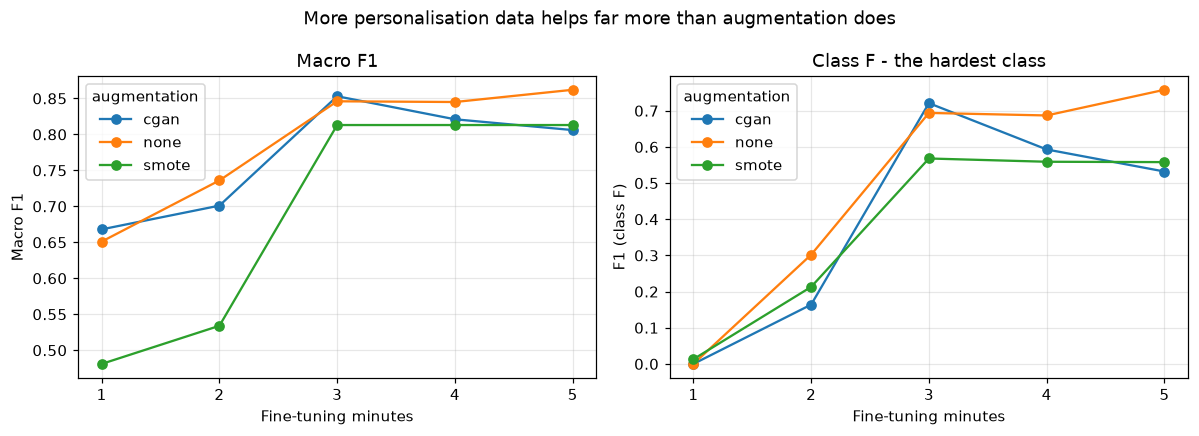

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
subset = results[results.extra_features == "none"]

for aug, group in subset.groupby("augmentation"):
    group = group.sort_values("train_minutes")
    axes[0].plot(group.train_minutes, group.macro_f1, marker="o", label=aug)
    axes[1].plot(group.train_minutes, group.f1_F, marker="o", label=aug)

axes[0].set(xlabel="Fine-tuning minutes", ylabel="Macro F1", title="Macro F1")
axes[1].set(xlabel="Fine-tuning minutes", ylabel="F1 (class F)",
            title="Class F - the hardest class")
for ax in axes:
    ax.legend(title="augmentation")
    ax.set_xticks(sorted(subset.train_minutes.unique()))
fig.suptitle("More personalisation data helps far more than augmentation does", fontsize=12)
fig.tight_layout()

## Per-class performance

Class F (fusion beats) is the weak point everywhere -- it is under 1% of the data
and morphologically sits between N and V.

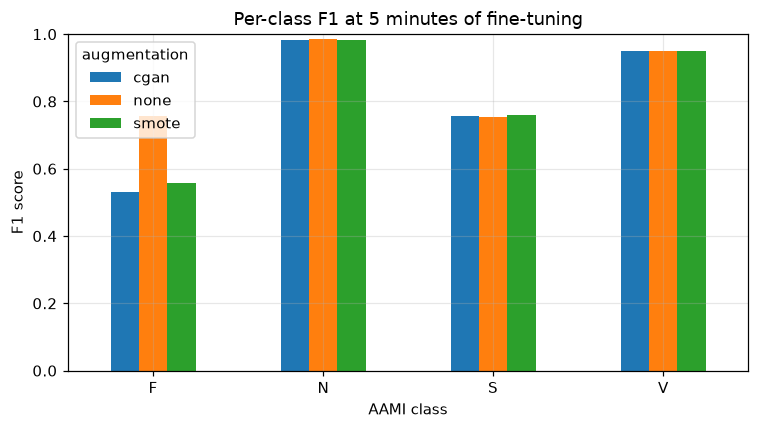

In [4]:
per_class = (results[(results.train_minutes == 5) & (results.extra_features == "none")]
             .set_index("augmentation")[[f"f1_{c}" for c in CLASSES]])
per_class.columns = list(CLASSES)

ax = per_class.T.plot.bar(figsize=(7, 4), rot=0)
ax.set(xlabel="AAMI class", ylabel="F1 score", ylim=(0, 1),
       title="Per-class F1 at 5 minutes of fine-tuning")
ax.legend(title="augmentation")
plt.tight_layout()

## Effect of the extra features

`LL` adds the gap to the previous beat, `HR` the instantaneous heart rate --
cheap scalar features prepended to the 151-sample window (giving 152 or 153
inputs). Both encode rhythm context that a single isolated beat cannot.

In [5]:
feature_effect = (results[(results.augmentation == "cgan") & (results.train_minutes == 5)]
                  .set_index("extra_features")[["accuracy", "macro_f1", "cohen_kappa"]])
feature_effect.loc[["none", "ll", "hr", "llhr"]]

,accuracy,macro_f1,cohen_kappa
extra_features,,,
none,0.969,0.806,0.849
ll,0.973,0.835,0.863
hr,0.980,0.848,0.897
llhr,0.981,0.851,0.901
